In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

import torch
from torch.utils.data  import Dataset , DataLoader
from torchvision import transforms
from PIL import Image
import os 
import torchvision
import numpy as np 

class CelebDataset(Dataset):
    def __init__(self, root_dir , transform=None):
        self.root_dir=root_dir
        self.transform = transform

        self.image_paths=[os.path.join(root_dir,img) for img in os.listdir(root_dir) if img.endswith('.jpg')]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self,idx):
        image_path=self.image_paths[idx]
        image=Image.open(image_path).convert('RGB')

        if self.transform:
            image=self.transform(image)

        return image
        
print(os.listdir("/kaggle/input/celeb-dataset-gan"))        

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

['img_align_celeba']


In [14]:
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.CenterCrop(64),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5,0.5,0.5],std=[0.5,0.5,0.5])
])
dataset_path="/kaggle/input/celeb-dataset-gan/img_align_celeba"
dataset = CelebDataset(root_dir=dataset_path,transform = transform)
dataloader = DataLoader(dataset, batch_size=128,shuffle=True)

print(f"total number of image loaded  : {len(dataset)}")

total number of image loaded  : 202599


In [15]:
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
import os 
from PIL import Image
import torchvision
import numpy as np 

class Generator(nn.Module):
    def __init__(self, z_dim=100,img_channels=3):
        super(Generator,self).__init__()
        self.model = nn.Sequential(
            nn.Linear(z_dim,256),
            nn.ReLU(True),
            nn.Linear(256,512),
            nn.ReLU(True),
            nn.Linear(512,1024),
            nn.ReLU(True),
            nn.Linear(1024,img_channels * 64 * 64),
            nn.Tanh()
    
        
        )
    def forward(self,z):
        img=self.model(z)
        img = img.view(img.size(0),3,64,64)
        return img


In [16]:
class Discriminator(nn.Module):
    def __init__(self,img_channels=3):
        super(Discriminator,self).__init__()
        self.model=nn.Sequential(
            nn.Flatten(),
            nn.Linear(img_channels * 64 * 64,1024),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(1024,512),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(512,256),
            nn.LeakyReLU(0.2,inplace=True),
            nn.Linear(256,1),
            nn.Sigmoid()      
        )
        
    def forward(self,img):
        return self.model(img)

In [17]:
adversarial_loss= nn.BCELoss()
generator = Generator(z_dim=100)

discriminator = Discriminator()

optimizer_G = optim.Adam(generator.parameters(),lr=0.0002,betas =(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(),lr=0.0002,betas =(0.5, 0.999))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

generator= generator.to(device)
discriminator = discriminator.to(device)

Using device: cuda


[Epoch 0/10] [Batch 0/1583] [D loss: 0.6877932548522949] [G loss: 0.6915374994277954]
[Epoch 0/10] [Batch 50/1583] [D loss: 0.2715435028076172] [G loss: 1.095158576965332]
[Epoch 0/10] [Batch 100/1583] [D loss: 0.15095071494579315] [G loss: 2.087632179260254]
[Epoch 0/10] [Batch 150/1583] [D loss: 0.41245579719543457] [G loss: 0.8537516593933105]
[Epoch 0/10] [Batch 200/1583] [D loss: 0.4007224440574646] [G loss: 0.6526477932929993]
[Epoch 0/10] [Batch 250/1583] [D loss: 0.06596238911151886] [G loss: 2.5161831378936768]
[Epoch 0/10] [Batch 300/1583] [D loss: 0.08638150990009308] [G loss: 2.3585383892059326]
[Epoch 0/10] [Batch 350/1583] [D loss: 0.437924325466156] [G loss: 2.1510934829711914]
[Epoch 0/10] [Batch 400/1583] [D loss: 0.36967986822128296] [G loss: 4.344334125518799]
[Epoch 0/10] [Batch 450/1583] [D loss: 0.3857647180557251] [G loss: 6.472451210021973]
[Epoch 0/10] [Batch 500/1583] [D loss: 0.06307224184274673] [G loss: 5.121109485626221]
[Epoch 0/10] [Batch 550/1583] [D lo

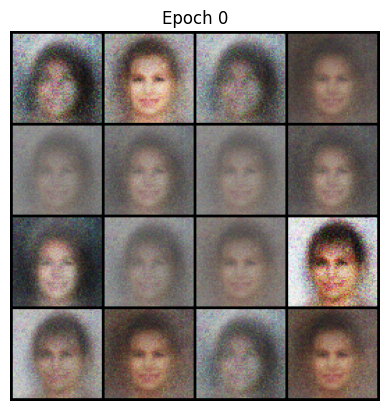

[Epoch 1/10] [Batch 0/1583] [D loss: 0.24789166450500488] [G loss: 3.702195405960083]
[Epoch 1/10] [Batch 50/1583] [D loss: 0.1723339557647705] [G loss: 2.7350120544433594]
[Epoch 1/10] [Batch 100/1583] [D loss: 0.17832928895950317] [G loss: 3.3196358680725098]
[Epoch 1/10] [Batch 150/1583] [D loss: 0.4068288803100586] [G loss: 6.332870006561279]
[Epoch 1/10] [Batch 200/1583] [D loss: 0.15673226118087769] [G loss: 3.544502019882202]
[Epoch 1/10] [Batch 250/1583] [D loss: 0.19015368819236755] [G loss: 3.180178642272949]
[Epoch 1/10] [Batch 300/1583] [D loss: 0.4045325219631195] [G loss: 2.7346458435058594]
[Epoch 1/10] [Batch 350/1583] [D loss: 0.17879259586334229] [G loss: 4.202228546142578]
[Epoch 1/10] [Batch 400/1583] [D loss: 0.156749427318573] [G loss: 3.253462314605713]
[Epoch 1/10] [Batch 450/1583] [D loss: 0.3563082218170166] [G loss: 4.264246463775635]
[Epoch 1/10] [Batch 500/1583] [D loss: 0.18909472227096558] [G loss: 3.4068307876586914]
[Epoch 1/10] [Batch 550/1583] [D loss

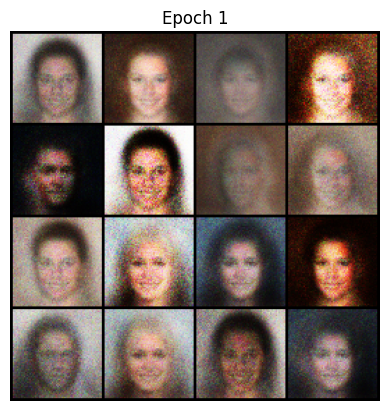

[Epoch 2/10] [Batch 0/1583] [D loss: 0.3066348731517792] [G loss: 2.119293689727783]
[Epoch 2/10] [Batch 50/1583] [D loss: 0.34641003608703613] [G loss: 3.000119924545288]
[Epoch 2/10] [Batch 100/1583] [D loss: 0.49942702054977417] [G loss: 3.1902565956115723]
[Epoch 2/10] [Batch 150/1583] [D loss: 0.35290002822875977] [G loss: 2.761960983276367]
[Epoch 2/10] [Batch 200/1583] [D loss: 0.3810093402862549] [G loss: 2.258646011352539]
[Epoch 2/10] [Batch 250/1583] [D loss: 0.6171292662620544] [G loss: 1.6829955577850342]
[Epoch 2/10] [Batch 300/1583] [D loss: 0.274077832698822] [G loss: 2.3401095867156982]
[Epoch 2/10] [Batch 350/1583] [D loss: 0.29189595580101013] [G loss: 2.378197193145752]
[Epoch 2/10] [Batch 400/1583] [D loss: 0.334140807390213] [G loss: 2.7776999473571777]
[Epoch 2/10] [Batch 450/1583] [D loss: 0.37997204065322876] [G loss: 2.0057146549224854]
[Epoch 2/10] [Batch 500/1583] [D loss: 0.4769171476364136] [G loss: 2.05171799659729]
[Epoch 2/10] [Batch 550/1583] [D loss: 

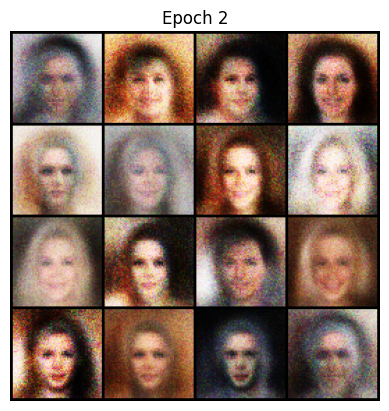

[Epoch 3/10] [Batch 0/1583] [D loss: 0.4006653428077698] [G loss: 2.6662845611572266]
[Epoch 3/10] [Batch 50/1583] [D loss: 0.5005708932876587] [G loss: 1.5931646823883057]
[Epoch 3/10] [Batch 100/1583] [D loss: 0.3934890031814575] [G loss: 2.5685744285583496]
[Epoch 3/10] [Batch 150/1583] [D loss: 0.4451746940612793] [G loss: 2.090907335281372]
[Epoch 3/10] [Batch 200/1583] [D loss: 0.4398411512374878] [G loss: 2.05489182472229]
[Epoch 3/10] [Batch 250/1583] [D loss: 0.6603357195854187] [G loss: 1.6911629438400269]
[Epoch 3/10] [Batch 300/1583] [D loss: 0.4580516815185547] [G loss: 2.451291084289551]
[Epoch 3/10] [Batch 350/1583] [D loss: 0.4264834523200989] [G loss: 2.6433563232421875]
[Epoch 3/10] [Batch 400/1583] [D loss: 0.4948232173919678] [G loss: 1.8428492546081543]
[Epoch 3/10] [Batch 450/1583] [D loss: 0.41602450609207153] [G loss: 2.082188129425049]
[Epoch 3/10] [Batch 500/1583] [D loss: 0.4858884811401367] [G loss: 2.918900966644287]
[Epoch 3/10] [Batch 550/1583] [D loss: 0

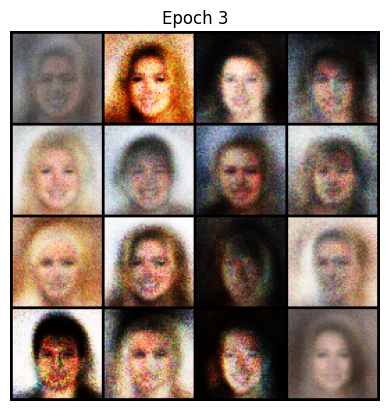

[Epoch 4/10] [Batch 0/1583] [D loss: 0.48756489157676697] [G loss: 1.9339351654052734]
[Epoch 4/10] [Batch 50/1583] [D loss: 0.45270633697509766] [G loss: 2.1681597232818604]
[Epoch 4/10] [Batch 100/1583] [D loss: 0.4444677531719208] [G loss: 1.676261067390442]
[Epoch 4/10] [Batch 150/1583] [D loss: 0.49844443798065186] [G loss: 1.6809349060058594]
[Epoch 4/10] [Batch 200/1583] [D loss: 0.42985770106315613] [G loss: 1.9693138599395752]
[Epoch 4/10] [Batch 250/1583] [D loss: 0.4192185699939728] [G loss: 2.0324714183807373]
[Epoch 4/10] [Batch 300/1583] [D loss: 0.4664493799209595] [G loss: 1.8132216930389404]
[Epoch 4/10] [Batch 350/1583] [D loss: 0.5648527145385742] [G loss: 1.906186580657959]
[Epoch 4/10] [Batch 400/1583] [D loss: 0.5144022703170776] [G loss: 2.300503969192505]
[Epoch 4/10] [Batch 450/1583] [D loss: 0.4929121732711792] [G loss: 1.545670509338379]
[Epoch 4/10] [Batch 500/1583] [D loss: 0.5056139230728149] [G loss: 1.8183740377426147]
[Epoch 4/10] [Batch 550/1583] [D lo

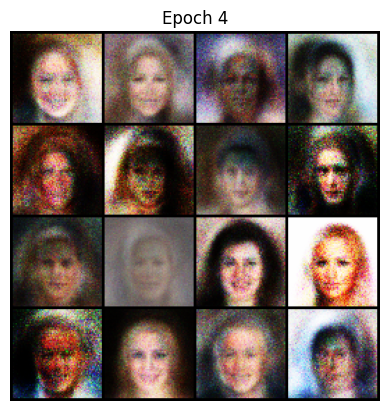

[Epoch 5/10] [Batch 0/1583] [D loss: 0.5504916310310364] [G loss: 1.3185900449752808]
[Epoch 5/10] [Batch 50/1583] [D loss: 0.4202651381492615] [G loss: 1.7603483200073242]
[Epoch 5/10] [Batch 100/1583] [D loss: 0.4749174118041992] [G loss: 1.882584810256958]
[Epoch 5/10] [Batch 150/1583] [D loss: 0.4488052725791931] [G loss: 1.4881839752197266]
[Epoch 5/10] [Batch 200/1583] [D loss: 0.4840688109397888] [G loss: 1.884232521057129]
[Epoch 5/10] [Batch 250/1583] [D loss: 0.5395139455795288] [G loss: 1.7082273960113525]
[Epoch 5/10] [Batch 300/1583] [D loss: 0.43875524401664734] [G loss: 1.5458245277404785]
[Epoch 5/10] [Batch 350/1583] [D loss: 0.4815139174461365] [G loss: 1.636061429977417]
[Epoch 5/10] [Batch 400/1583] [D loss: 0.5573858022689819] [G loss: 1.3604528903961182]
[Epoch 5/10] [Batch 450/1583] [D loss: 0.43481308221817017] [G loss: 1.63650381565094]
[Epoch 5/10] [Batch 500/1583] [D loss: 0.6768335103988647] [G loss: 1.3567087650299072]
[Epoch 5/10] [Batch 550/1583] [D loss:

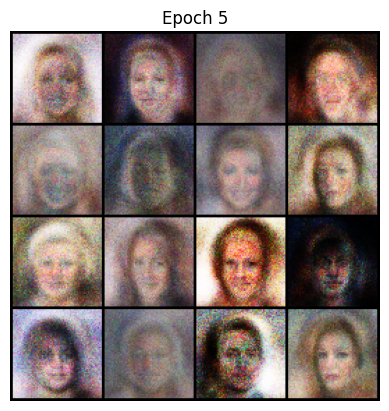

[Epoch 6/10] [Batch 0/1583] [D loss: 0.5619940757751465] [G loss: 1.4525959491729736]
[Epoch 6/10] [Batch 50/1583] [D loss: 0.48221296072006226] [G loss: 1.6112167835235596]
[Epoch 6/10] [Batch 100/1583] [D loss: 0.45923107862472534] [G loss: 1.6399649381637573]
[Epoch 6/10] [Batch 150/1583] [D loss: 0.5243306756019592] [G loss: 1.6821513175964355]
[Epoch 6/10] [Batch 200/1583] [D loss: 0.48104435205459595] [G loss: 1.6687909364700317]
[Epoch 6/10] [Batch 250/1583] [D loss: 0.478145956993103] [G loss: 1.4158968925476074]
[Epoch 6/10] [Batch 300/1583] [D loss: 0.49973562359809875] [G loss: 1.733164668083191]
[Epoch 6/10] [Batch 350/1583] [D loss: 0.44601938128471375] [G loss: 1.608483076095581]
[Epoch 6/10] [Batch 400/1583] [D loss: 0.5171142220497131] [G loss: 1.4946486949920654]
[Epoch 6/10] [Batch 450/1583] [D loss: 0.4055013358592987] [G loss: 1.6111767292022705]
[Epoch 6/10] [Batch 500/1583] [D loss: 0.5333950519561768] [G loss: 1.5176078081130981]
[Epoch 6/10] [Batch 550/1583] [D 

In [ ]:
def train(generator, discriminator, dataloader, epochs=5):
    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)
            valid = torch.ones(batch_size, 1).to(device)
            fake = torch.zeros(batch_size, 1).to(device)

            # Train Discriminator
            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device)).detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            # Train Generator
            optimizer_G.zero_grad()
            g_loss = adversarial_loss(discriminator(generator(torch.randn(batch_size, 100).to(device))), valid)
            g_loss.backward()
            optimizer_G.step()
            if i % 50 == 0:
                print(f"[Epoch {epoch}/{epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

        # Optionally, save generated images at each epoch
        save_generated_images(generator, epoch, device)

def save_generated_images(generator, epoch, device, num_images=16):
    z = torch.randn(num_images, 100).to(device)
    generated_imgs = generator(z).detach().cpu()
    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)
    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"Epoch {epoch}")
    plt.axis('off')
    plt.show()

# Start training
train(generator, discriminator, dataloader, epochs=10)